<a href="https://colab.research.google.com/github/TaranpreetKaur06/E-Commerce-customer-segmentation/blob/main/E_Commerce_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing liabraries

In [2]:
# =======================
# IMPORT LIABRARIES
# =======================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#ignore wwarnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Importing dataset

In [5]:
df = pd.read_excel('part_1_ecommerce_customer_segmentation.xlsx')


# Data understanding

In [6]:
#first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [7]:
# total columns and rows
df.shape
# there are 9 columns and 4395 rows...

(4395, 9)

In [8]:
# display column name
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Category', 'Quantity',
       'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# display data info like data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4395 non-null   object        
 1   StockCode    4395 non-null   object        
 2   Description  4328 non-null   object        
 3   Category     4395 non-null   object        
 4   Quantity     4395 non-null   int64         
 5   InvoiceDate  4395 non-null   datetime64[ns]
 6   UnitPrice    4395 non-null   float64       
 7   CustomerID   4187 non-null   object        
 8   Country      4395 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 309.2+ KB


In [10]:
# discribe data information
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,4395.000000,4395,4395.000000
mean,2.826394,2025-06-13 22:25:17.597269504,747.081477
min,-50.000000,2025-01-02 14:47:00,-2244.520000
25%,1.000000,2025-03-20 14:25:00,328.200000
50%,2.000000,2025-06-14 15:03:00,544.320000
75%,4.000000,2025-09-04 22:52:00,950.470000
max,50.000000,2025-11-27 19:27:00,2939.580000
std,3.846051,NaN,611.134932


# DATA CLEANING

In [12]:
# DATA CLEANING

# checking for nulls

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,67
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,208
Country,0


In [15]:
# drop rows with missing customer ID
df = df.dropna(subset=['CustomerID'])

In [16]:
# drop missing product discription rows
df = df.dropna(subset=['Description'])

In [17]:
# checking for qunatity less than 0
df[df['Quantity'] < 0 ]

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
11,CINV500004,P1003,Running Shoes,Footwear,-2,2025-07-23 21:51:00,2458.32,C10742,EIRE
13,CINV500004,P1013,LED Table Lamp,Home,-1,2025-07-23 21:51:00,1450.45,C10742,EIRE
58,INV500021,P1013,LED Table Lamp,Home,-5,2025-08-01 08:25:00,1390.69,C10028,United Kingdom
106,CINV500035,P1004,Leather Wallet,Accessories,-2,2025-02-21 14:21:00,922.43,C10054,Portugal
107,CINV500035,P1022,Dark Chocolate Box,Grocery,-10,2025-02-21 14:21:00,513.66,C10054,Portugal
...,...,...,...,...,...,...,...,...,...
4294,CINV501429,P1009,Yoga Mat,Fitness,-1,2025-04-09 12:31:00,912.80,C10328,Portugal
4295,CINV501429,P1003,Running Shoes,Footwear,-4,2025-04-09 12:31:00,2805.35,C10328,Portugal
4296,CINV501429,P1014,Travel Backpack,Travel,-1,2025-04-09 12:31:00,1444.15,C10328,Portugal
4384,CINV500593,P1023,Water Bottle,Fitness,-1,2025-10-13 22:51:00,554.90,C10612,United Kingdom


In [18]:
# removing negative or zero quantities
df = df[df['Quantity'] > 0]

In [19]:
# checking for unit price less than 0 or negative
df[df['UnitPrice'] < 0 ]

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
187,INV500061,P1002,Denim Jacket,Apparel,1,2025-05-17 21:32:00,-2093.08,C10587,United Kingdom
413,INV500139,P1008,Scented Candle Set,Home,2,2025-08-09 21:46:00,-609.83,C10649,United Kingdom
1347,INV500457,P1006,Wireless Mouse,Electronics,3,2025-06-17 15:25:00,-773.23,C10398,United Kingdom
1456,INV500496,P1019,Phone Stand,Electronics,2,2025-08-02 22:29:00,-245.64,C10486,Australia
1493,INV500510,P1024,Laptop Sleeve,Accessories,1,2025-02-20 12:55:00,-1047.43,C10261,Netherlands
1582,INV500545,P1016,Face Serum,Beauty,1,2025-10-21 20:28:00,-868.28,C10235,United Kingdom
1789,INV500608,P1005,Bluetooth Speaker,Electronics,2,2025-09-03 16:17:00,-2031.94,C10248,United Kingdom
2235,INV500749,P1024,Laptop Sleeve,Accessories,1,2025-01-24 10:44:00,-832.31,C10184,United Kingdom
2279,INV500764,P1011,Desk Organizer,Office,1,2025-05-13 08:11:00,-390.27,C10297,United Kingdom
2285,INV500766,P1024,Laptop Sleeve,Accessories,1,2025-03-21 10:49:00,-866.13,C10690,India


In [20]:
# removing rows with negative or Zero unit prices
df = df[df['UnitPrice'] > 0]

In [107]:
# Identify invoices where InvoiceNo starts with 'C'
cancelled_invoices = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Number of cancelled or returned invoices: {len(cancelled_invoices)}")

if not cancelled_invoices.empty:
    print("First 5 cancelled or returned invoices:")
    display(cancelled_invoices.head())
else:
    print("No cancelled or returned invoices found in the cleaned dataset.")

Number of cancelled or returned invoices: 0
No cancelled or returned invoices found in the cleaned dataset.


In [26]:
# Checking for duplicates
print( "number of Duplicated rows = " , (df.duplicated().sum()) )

number of Duplicated rows =  31


In [27]:
# removing duplicates
df = df.drop_duplicates()

In [29]:
# checking datatypes of all columns
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Category,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,object
Country,object


In [38]:
#checking dataset after data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3848 entries, 0 to 4359
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3848 non-null   object        
 1   StockCode    3848 non-null   object        
 2   Description  3848 non-null   object        
 3   Category     3848 non-null   object        
 4   Quantity     3848 non-null   int64         
 5   InvoiceDate  3848 non-null   datetime64[ns]
 6   UnitPrice    3848 non-null   float64       
 7   CustomerID   3848 non-null   object        
 8   Country      3848 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 300.6+ KB


In [39]:
# checking for data shape after data cleaning
df.shape

(3848, 9)

### Feature Engineering: Total Revenue per Customer

In [ ]:
# Calculate 'TotalSales' for each transaction
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

In [45]:
# Group by 'CustomerID' and sum 'TotalSales' to get 'TotalRevenue'
customer_revenue = df.groupby('CustomerID')['TotalSales'].sum().reset_index()
customer_revenue.rename(columns={'TotalSales': 'TotalRevenue'}, inplace=True)


# Display the first few rows
print("Total Revenue per Customer:")
display(customer_revenue.head())

Total Revenue per Customer:


,CustomerID,TotalRevenue
0,C10001,22885.81
1,C10003,12061.04
2,C10004,10579.97
3,C10005,14154.57
4,C10006,27389.29


In [46]:
# Calculate 'TotalNumberOfPurchases' for each customer
customer_purchases = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_purchases.rename(columns={'InvoiceNo': 'TotalNumberOfPurchases'}, inplace=True)


# Display the first few rows
print("Total Number of Purchases per Customer:")
display(customer_purchases.head())


Total Number of Purchases per Customer:


,CustomerID,TotalNumberOfPurchases
0,C10001,3
1,C10003,1
2,C10004,2
3,C10005,2
4,C10006,3


In [47]:
# Calculate 'TotalQuantityPurchased' for each customer
customer_total_quantity = df.groupby('CustomerID')['Quantity'].sum().reset_index()
customer_total_quantity.rename(columns={'Quantity': 'TotalQuantityPurchased'}, inplace=True)

# Display the first few rows
print("Total Quantity Purchased per Customer:")
display(customer_total_quantity.head())

Total Quantity Purchased per Customer:


,CustomerID,TotalQuantityPurchased
0,C10001,63
1,C10003,10
2,C10004,16
3,C10005,17
4,C10006,27


In [48]:
# Calculate 'AverageOrderValue' for each customer
customer_avg_order_value = df.groupby('CustomerID')['TotalSales'].mean().reset_index()
customer_avg_order_value.rename(columns={'TotalSales': 'AverageOrderValue'}, inplace=True)

# Display the first few rows of the 'customer_avg_order_value' DataFrame
print("Average Order Value per Customer:")
display(customer_avg_order_value.head())

Average Order Value per Customer:


,CustomerID,AverageOrderValue
0,C10001,2860.726250
1,C10003,4020.346667
2,C10004,1511.424286
3,C10005,2022.081429
4,C10006,3043.254444


In [49]:
# Calculate 'NumberOfUniqueProductsPurchased' for each customer
customer_unique_products = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
customer_unique_products.rename(columns={'StockCode': 'NumberOfUniqueProductsPurchased'}, inplace=True)

# Display the first few rows of the 'customer_unique_products' DataFrame
print("Number of Unique Products Purchased per Customer:")
display(customer_unique_products.head())

Number of Unique Products Purchased per Customer:


,CustomerID,NumberOfUniqueProductsPurchased
0,C10001,8
1,C10003,3
2,C10004,5
3,C10005,7
4,C10006,8


In [53]:
# Create a DataFrame mapping each CustomerID to their Country
# Assuming each customer is primarily associated with a single country based on the first occurrence
customer_country_map = df.groupby('CustomerID')['Country'].first().reset_index()

# Display the first few rows of the customer_country_map DataFrame
print("Country for each Customer:")
display(customer_country_map.head())

Country for each Customer:


,CustomerID,Country
0,C10001,India
1,C10003,United Kingdom
2,C10004,United Kingdom
3,C10005,Germany
4,C10006,India


### RFM Feature Engineering

In [56]:
# Calculate Recency: Days since last purchase
# First, find the most recent InvoiceDate in the entire dataset
max_invoice_date = df['InvoiceDate'].max()

# Calculate Recency for each customer
customer_recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
customer_recency['Recency'] = (max_invoice_date - customer_recency['InvoiceDate']).dt.days

# Display the first few rows of the 'customer_recency' DataFrame
print("Recency (Days since last purchase) per Customer:")
display(customer_recency.head())

Recency (Days since last purchase) per Customer:


,CustomerID,InvoiceDate,Recency
0,C10001,2025-08-03 17:27:00,116
1,C10003,2025-10-26 12:49:00,32
2,C10004,2025-10-19 10:11:00,39
3,C10005,2025-02-04 15:14:00,296
4,C10006,2025-10-28 13:36:00,30


In [57]:
# Create the RFM table by merging the calculated features

# Start with customer_revenue (which has CustomerID and Monetary)
rfm_table = customer_revenue[['CustomerID', 'TotalRevenue']]
rfm_table.rename(columns={'TotalRevenue': 'Monetary'}, inplace=True)

# Merge with customer_purchases (Frequency)
rfm_table = pd.merge(rfm_table, customer_purchases[['CustomerID', 'TotalNumberOfPurchases']], on='CustomerID', how='left')
rfm_table.rename(columns={'TotalNumberOfPurchases': 'Frequency'}, inplace=True)

# Merge with customer_recency (Recency)
rfm_table = pd.merge(rfm_table, customer_recency[['CustomerID', 'Recency']], on='CustomerID', how='left')

# Display the first few rows of the RFM table
print("\nRFM Table:")
display(rfm_table.head())


RFM Table:


,CustomerID,Monetary,Frequency,Recency
0,C10001,22885.81,3,116
1,C10003,12061.04,1,32
2,C10004,10579.97,2,39
3,C10005,14154.57,2,296
4,C10006,27389.29,3,30


# Exploratory Data Analysis

## Ques1: What country generated the highest sales

In [61]:
# Calculate total sales per country
country_sales = df.groupby('Country')['TotalSales'].sum().reset_index()

# Find the country with the highest sales
highest_sales_country = country_sales.loc[country_sales['TotalSales'].idxmax()]

print("Country with the Highest Sales:")
display(highest_sales_country)

print("\nAll Countries by Total Sales (Top 10):")
display(country_sales.sort_values(by='TotalSales', ascending=False).head(10))

Country with the Highest Sales:


,10
Country,United Kingdom
TotalSales,5077346.04



All Countries by Total Sales (Top 10):


,Country,TotalSales
10,United Kingdom,5077346.04
5,India,1317559.20
4,Germany,522952.30
6,Netherlands,471859.80
3,France,391165.98
2,EIRE,363629.09
8,Singapore,274964.06
9,Spain,245251.64
0,Australia,207927.20
1,Canada,186286.15


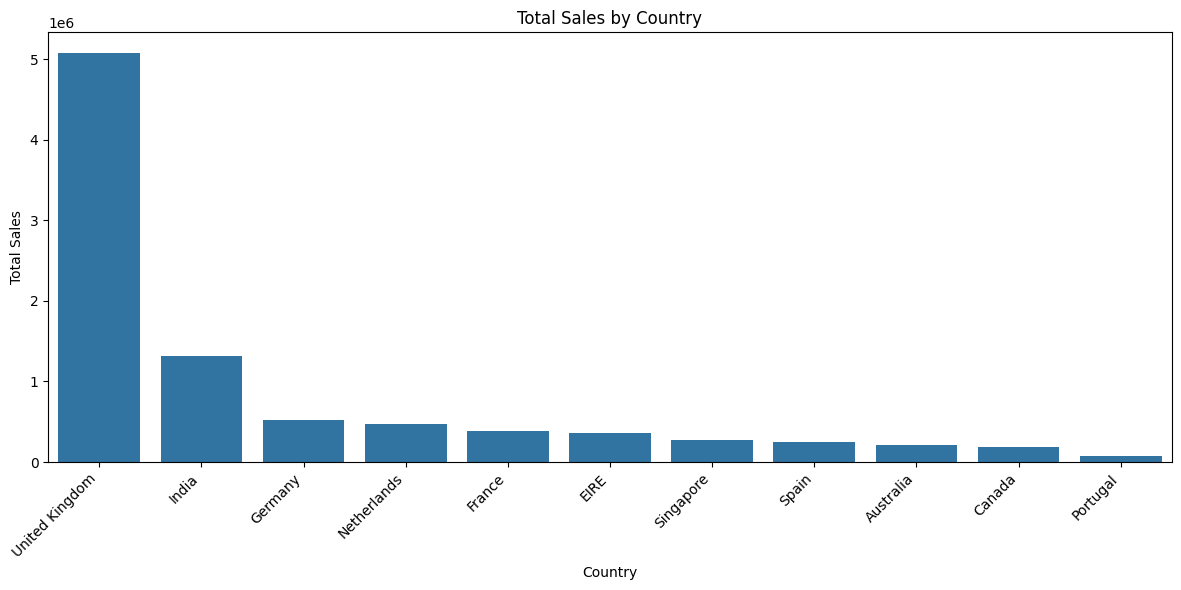

In [69]:
# Visualize total sales by country
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='TotalSales', data=country_sales.sort_values(by='TotalSales', ascending=False ))
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This bar chart illustrates that the **United Kingdom** has by far the highest total sales compared to all other countries, indicating it is the primary market for this e-commerce business.

# Ques2: Which Products are sold the most

In [66]:
# Calculate the total quantity sold for each product
product_sales = df.groupby('Description')['Quantity'].sum().reset_index()

# Sort by quantity in descending order
most_sold_products = product_sales.sort_values(by='Quantity', ascending=False)

print("Top 10 Most Sold Products (by Quantity):")
display(most_sold_products.head(10))

Top 10 Most Sold Products (by Quantity):


,Description,Quantity
26,USB-C Cable,485
2,Cotton Bedsheet,457
22,Smart Watch Strap,453
15,Notebook Pack,444
8,Gift Wrapping Paper,440
27,Water Bottle,434
23,Sports Socks Pack,432
3,Dark Chocolate Box,429
19,Protein Shaker,428
28,Wireless Mouse,427


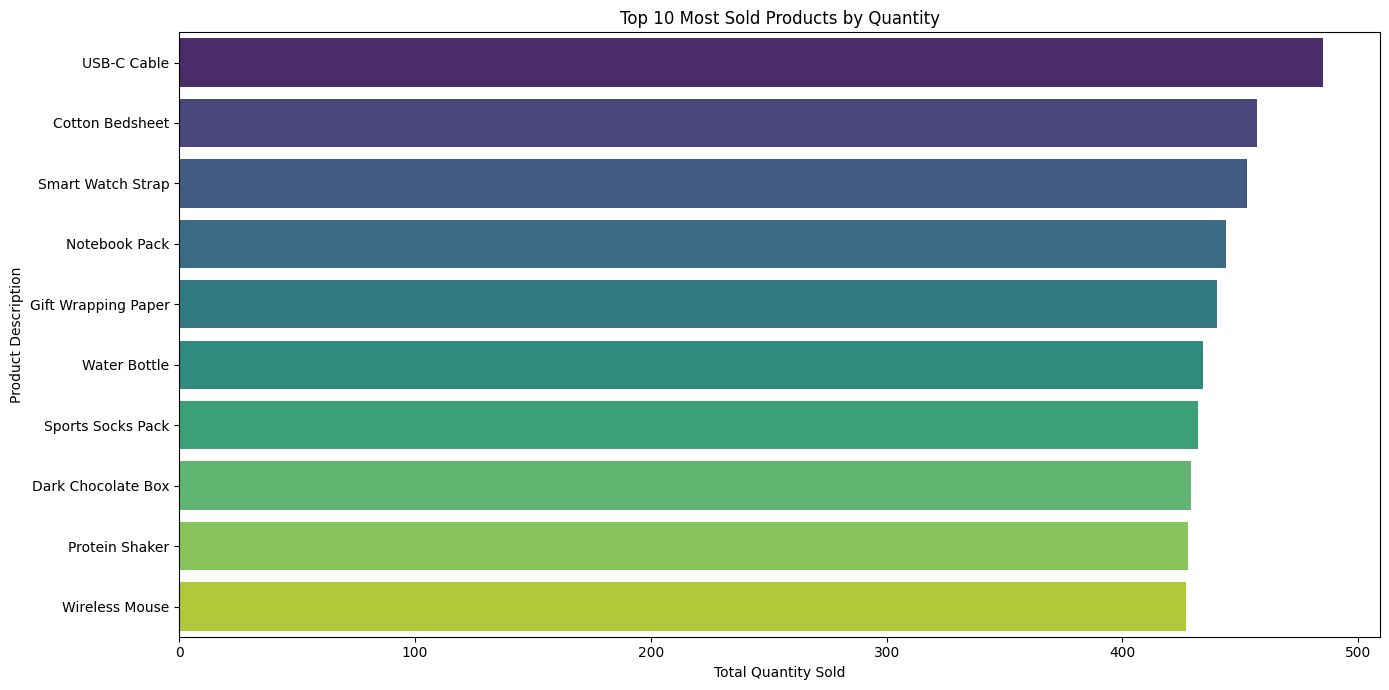

In [67]:
# Visualize the top 10 most sold products
plt.figure(figsize=(14, 7))
sns.barplot(x='Quantity', y='Description', data=most_sold_products.head(10), palette='viridis')
plt.title('Top 10 Most Sold Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

This bar chart shows the **Top 10 Most Sold Products by Quantity**. The 'USB-C Cable' is the most sold item, followed closely by 'Cotton Bedsheet' and 'Smart Watch Strap', highlighting popular high-volume products.

# Ques3: Which product generate the highest revenue?

In [70]:
# Calculate the total revenue for each product
product_revenue = df.groupby('Description')['TotalSales'].sum().reset_index()

# Sort by total revenue in descending order
highest_revenue_products = product_revenue.sort_values(by='TotalSales', ascending=False)

print("Top 10 Products by Total Revenue:")
display(highest_revenue_products.head(10))

Top 10 Products by Total Revenue:


,Description,TotalSales
0,Bluetooth Speaker,936458.19
20,Running Shoes,882656.10
4,Denim Jacket,725974.85
25,Travel Backpack,592789.30
2,Cotton Bedsheet,592381.23
11,LED Table Lamp,468922.36
9,Hair Care Kit,388105.56
29,Yoga Mat,362532.24
12,Laptop Sleeve,361688.20
7,Face Serum,341787.55


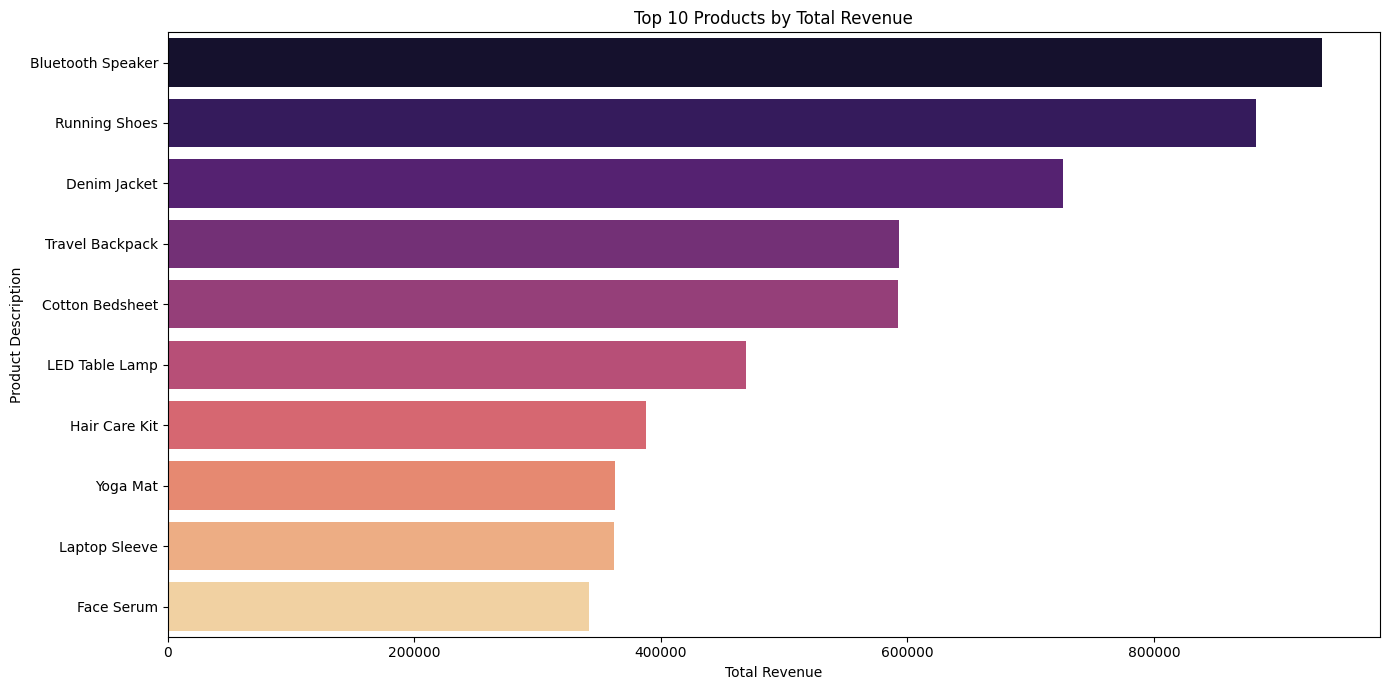

In [71]:
# Visualize the top 10 products by total revenue
plt.figure(figsize=(14, 7))
sns.barplot(x='TotalSales', y='Description', data=highest_revenue_products.head(10), palette='magma')
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

This bar chart presents the **Top 10 Products by Total Revenue**. The 'Bluetooth Speaker' generates significantly more revenue than other products, followed by 'Running Shoes' and 'Denim Jacket', indicating their high value contributions.

# Ques 4: What is the distribution of customer purchase frequency?

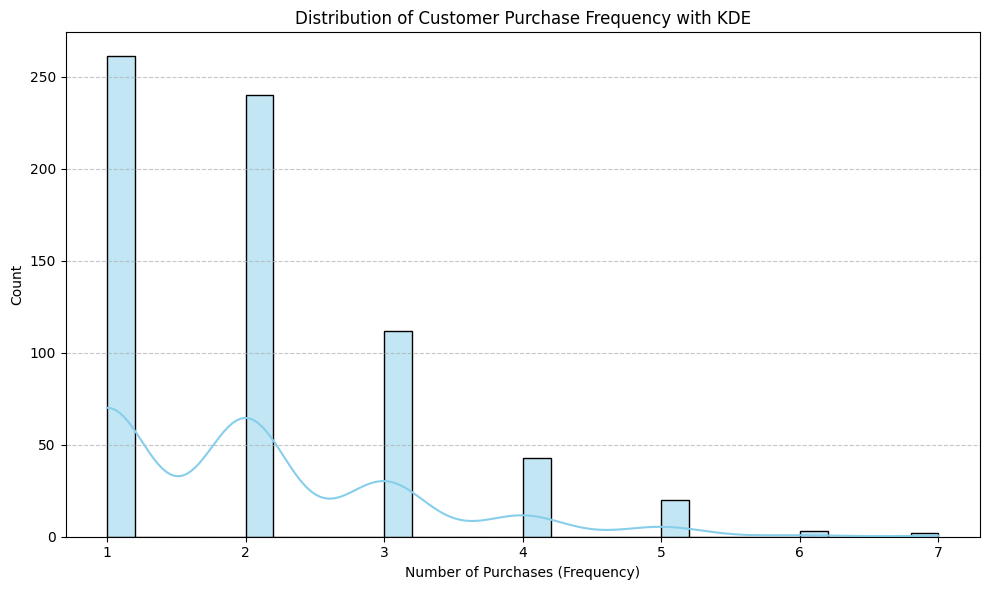

In [75]:
# Plot the customer purchase frequency histogram with a KDE overlay
plt.figure(figsize=(10, 6))
sns.histplot(rfm_table['Frequency'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Customer Purchase Frequency with KDE')
plt.xlabel('Number of Purchases (Frequency)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This histogram displays the **Distribution of Customer Purchase Frequency**. It shows that a large number of customers make a low number of purchases, with the frequency decreasing as the number of purchases increases. The KDE line smooths this distribution.

# Ques 5: What is the distribution of order value?

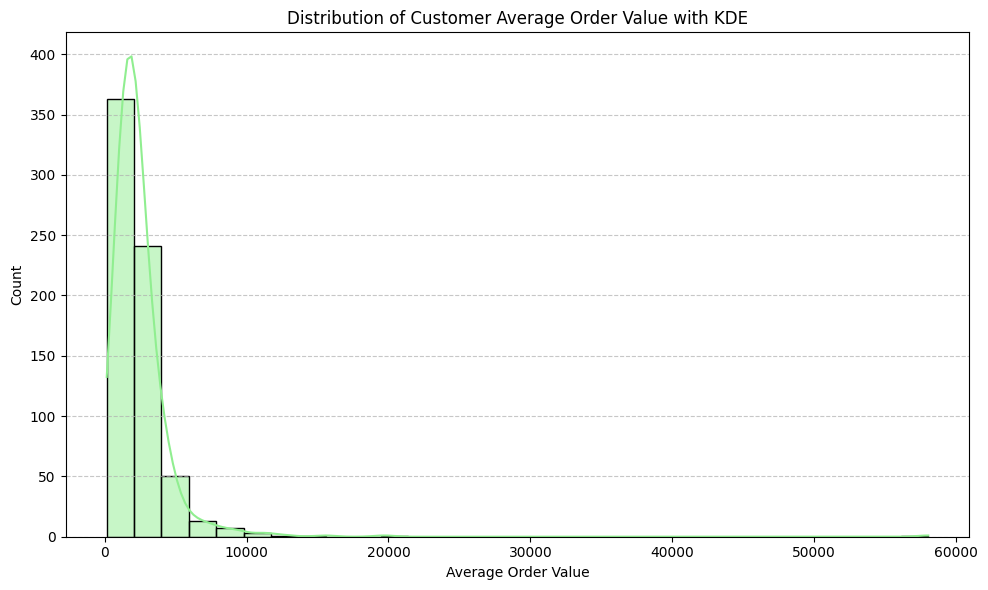

In [77]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_avg_order_value['AverageOrderValue'], bins=30, kde=True, color='lightgreen', edgecolor='black')
plt.title('Distribution of Customer Average Order Value with KDE')
plt.xlabel('Average Order Value')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This histogram illustrates the **Distribution of Customer Average Order Value**. The majority of customers have an average order value concentrated in the lower to mid-range, with fewer customers having very high average order values. The KDE line helps visualize the density.

# Ques 6: Are there outliers in Quantity, price or revenue?

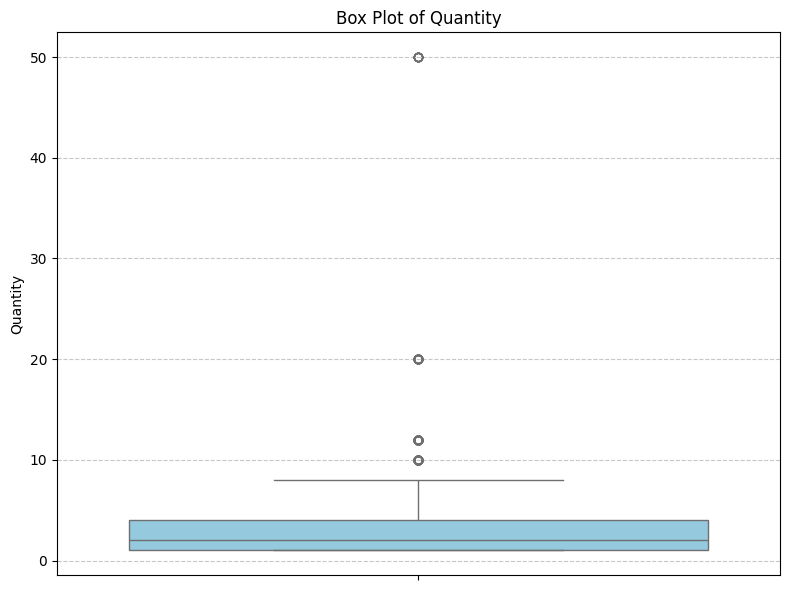

In [81]:
# Box plot for Quantity
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Quantity'], color='skyblue')
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This box plot for **Quantity** shows a distribution with many outliers, particularly on the higher side. This suggests that while most transactions involve small quantities, there are occasional large-volume purchases.

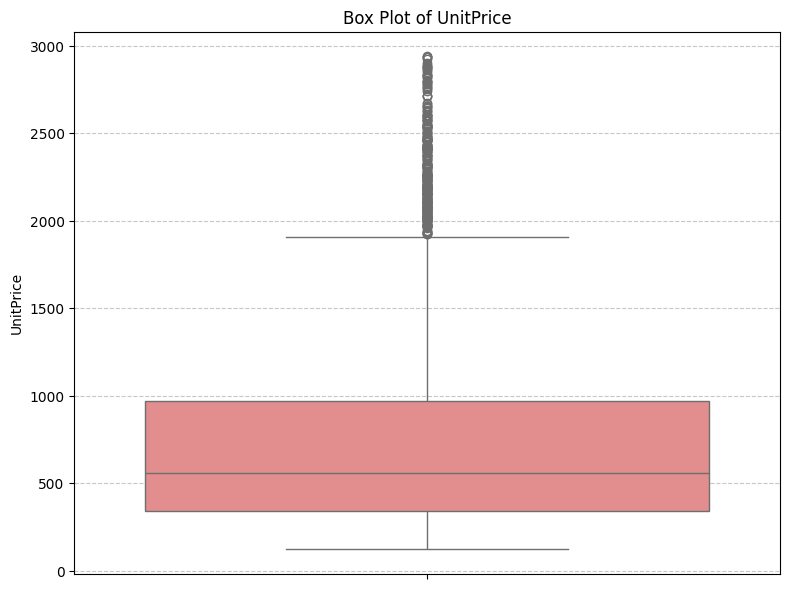

In [82]:
# Box plot for UnitPrice
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['UnitPrice'], color='lightcoral')
plt.title('Box Plot of UnitPrice')
plt.ylabel('UnitPrice')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The box plot for **UnitPrice** indicates a wide range of product prices, with several outliers at higher price points. This implies the presence of both affordable and premium products in the dataset.

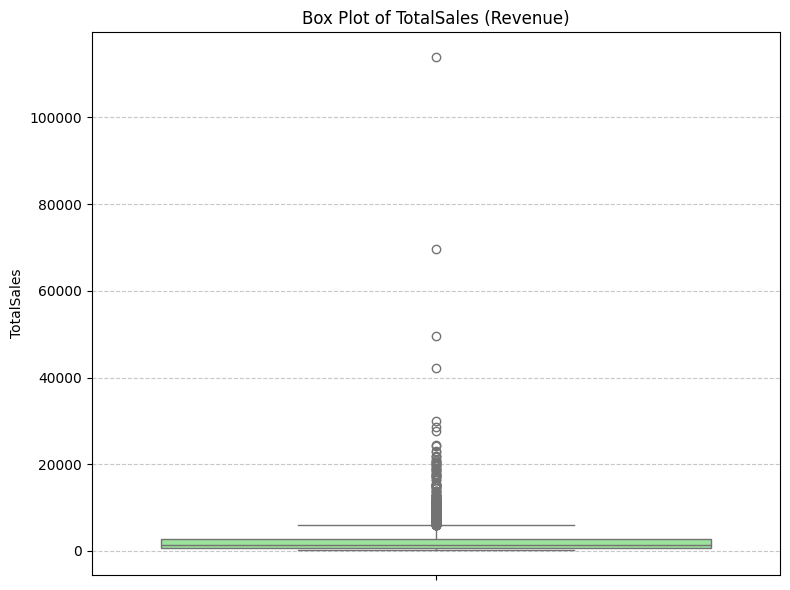

In [83]:
# Box plot for TotalSales (Revenue)
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['TotalSales'], color='lightgreen')
plt.title('Box Plot of TotalSales (Revenue)')
plt.ylabel('TotalSales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This box plot for **TotalSales (Revenue)** reveals a distribution with numerous high-value outliers. This suggests that a few transactions generate significantly higher revenue than the average, contributing disproportionately to overall sales.

# Ques 7: Which customers appear to be high value customer?

RFM Table with individual R, F, M Scores and combined RFM_Score:


,CustomerID,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,IsHighValue
0,C10001,22885.81,3,116,2,2,4,335,8,True
1,C10003,12061.04,1,32,4,1,3,513,8,False
2,C10004,10579.97,2,39,4,1,3,423,8,False
3,C10005,14154.57,2,296,1,1,3,124,5,False
4,C10006,27389.29,3,30,4,2,4,535,10,True



Top 10 High-Value Customers based on overall RFM Score:


,CustomerID,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,IsHighValue
656,C10821,45211.34,6,21,4,3,4,555,11,True
227,C10280,19932.81,4,37,4,3,4,434,11,True
20,C10028,21765.78,5,3,4,3,4,545,11,True
628,C10783,47664.98,4,24,4,3,4,535,11,True
587,C10738,24838.99,4,21,4,3,4,535,11,True
568,C10710,51428.10,4,20,4,3,4,535,11,True
489,C10597,23659.57,5,7,4,3,4,545,11,True
480,C10587,22423.31,4,20,4,3,4,535,11,True
535,C10657,19219.48,4,11,4,3,4,534,11,True
81,C10101,23502.25,4,30,4,3,4,535,11,True


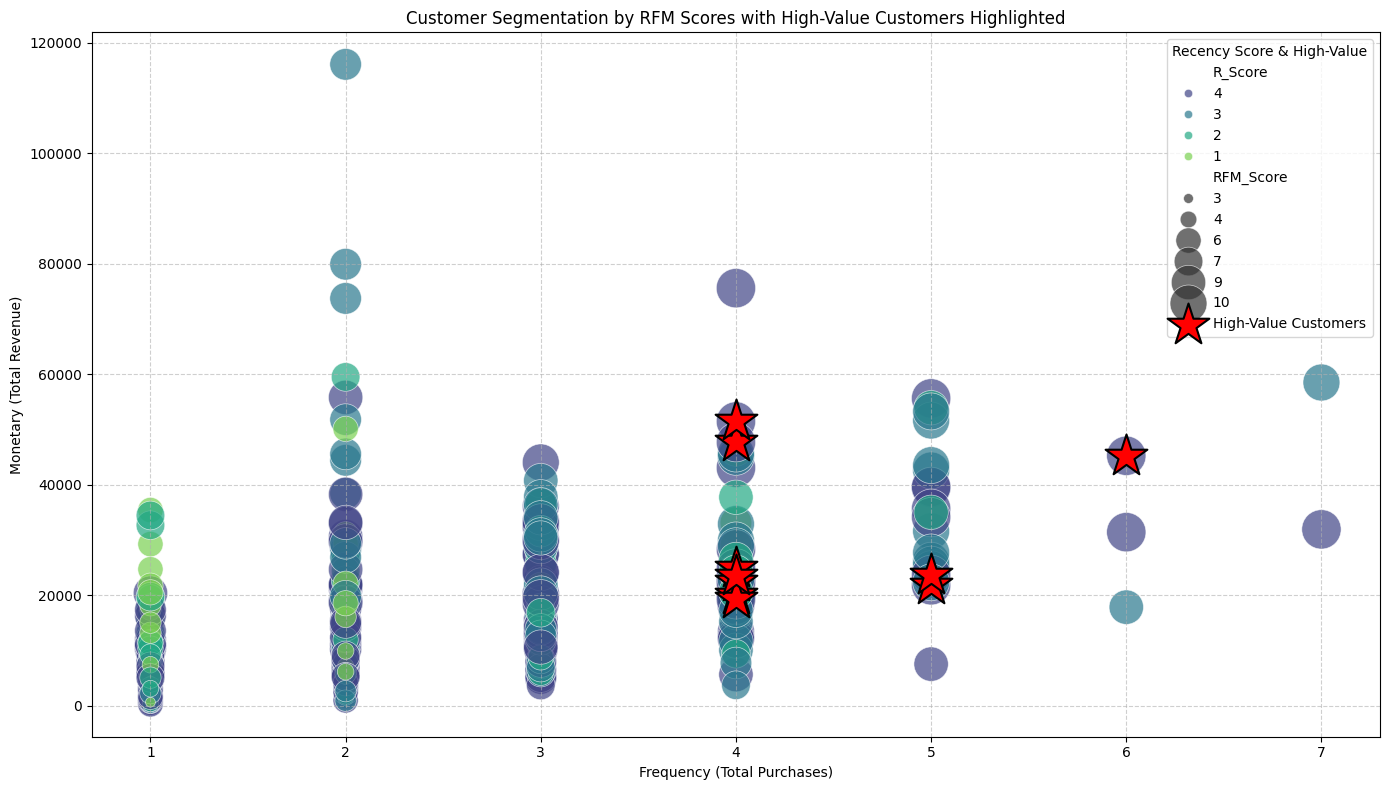

In [100]:
# Assign RFM scores based on quartiles
# Recency: Lower value is better, so we reverse the scoring (higher quartile = lower recency = higher score)
rfm_table['R_Score'] = pd.qcut(rfm_table['Recency'], 4, labels=[4, 3, 2, 1], duplicates='drop')

# Frequency: Higher value is better
# Dynamically determine the number of actual bins qcut can form by getting the bin edges.
# This handles cases where there aren't enough unique values to form 4 distinct quantiles.
_, bins_f_edges = pd.qcut(rfm_table['Frequency'], q=4, duplicates='drop', retbins=True)

# The number of actual bins is one less than the number of bin edges
num_actual_bins_f = len(bins_f_edges) - 1

# Only proceed with assigning F_Score if at least one bin could be formed
if num_actual_bins_f > 0:
    # Create labels dynamically, ensuring they are in ascending order for F_Score (higher frequency = higher score)
    # The labels list length must match the number of actual bins
    labels_f = list(range(1, num_actual_bins_f + 1))

    # Use pd.cut with the determined bins and labels to assign scores
    rfm_table['F_Score'] = pd.cut(
        rfm_table['Frequency'],
        bins=bins_f_edges,
        labels=labels_f,
        include_lowest=True, # Include the minimum value in the first bin
        right=True # Bins are (a, b], as is standard for quantiles
    )
else:
    # If no bins could be formed (e.g., all 'Frequency' values are identical),
    # assign a default score (e.g., 1) to all customers for Frequency.
    rfm_table['F_Score'] = 1

# Monetary: Higher value is better
rfm_table['M_Score'] = pd.qcut(rfm_table['Monetary'], 4, labels=[1, 2, 3, 4], duplicates='drop')

# Calculate the overall RFM score (sum of R, F, M scores)
rfm_table['RFM_Score'] = rfm_table['R_Score'].astype(int) + \
                               rfm_table['F_Score'].astype(int) + \
                               rfm_table['M_Score'].astype(int)

print("RFM Table with individual R, F, M Scores and combined RFM_Score:")
display(rfm_table.head())

# Identify High-Value Customers (e.g., top 10 based on RFM_Score)
high_value_customers = rfm_table.sort_values(by='RFM_Score', ascending=False).head(10)

print("\nTop 10 High-Value Customers based on overall RFM Score:")
display(high_value_customers)

# Visualization: Scatter plot of Frequency vs. Monetary, highlighting top customers
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='R_Score', # Color by Recency Score
    size='RFM_Score', # Size by overall RFM Score
    data=rfm_table,
    palette='viridis',
    sizes=(50, 800), # Adjust size range for better visibility
    alpha=0.7,
    edgecolor='w', # Add white edge for better separation
    linewidth=0.5
)

# Highlight high-value customers by plotting them again with a distinct style
sns.scatterplot(
    x='Frequency',
    y='Monetary',
    data=high_value_customers,
    color='red', # Highlight in red
    marker='*', # Use a star marker
    s=1000, # Make the marker larger
    label='High-Value Customers',
    edgecolor='black',
    linewidth=1.5,
    zorder=5 # Ensure these points are drawn on top
)

plt.title('Customer Segmentation by RFM Scores with High-Value Customers Highlighted')
plt.xlabel('Frequency (Total Purchases)')
plt.ylabel('Monetary (Total Revenue)')
plt.legend(title='Recency Score & High-Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This scatter plot visualizes **Customer Segmentation by RFM Scores**, with high-value customers prominently highlighted by red star markers. These high-value customers generally exhibit higher frequency and monetary values, with their overall RFM score determining marker size and Recency score influencing color for other customers.

# Customer Segmentation using K-Means

**Selecting relevant features for clustering**

In [102]:
# Select R, F, M features for clustering
rfm_features = rfm_table[['Recency', 'Frequency', 'Monetary']]

print("RFM features for clustering:")
display(rfm_features.head())

RFM features for clustering:


,Recency,Frequency,Monetary
0,116,3,22885.81
1,32,1,12061.04
2,39,2,10579.97
3,296,2,14154.57
4,30,3,27389.29


### Normalize or scale the data
K-Means clustering is sensitive to the scale of the features. Therefore, we will use `StandardScaler` to normalize the `Recency`, `Frequency`, and `Monetary` values.

In [103]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the RFM features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert the scaled data back to a DataFrame for better readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns, index=rfm_features.index)

print("Scaled RFM features:")
display(rfm_scaled_df.head())

Scaled RFM features:


,Recency,Frequency,Monetary
0,-0.080051,0.884554,0.753723
1,-1.020730,-0.935329,-0.107681
2,-0.942340,-0.025388,-0.225540
3,1.935690,-0.025388,0.058916
4,-1.043127,0.884554,1.112097


### Use the elbow method to choose a suitable number of clusters
The Elbow Method helps determine the optimal number of clusters (`k`) by looking for a 'bend' in the plot of WCSS (Within-Cluster Sum of Squares) against the number of clusters. The point where the rate of decrease in WCSS significantly changes is considered the elbow, suggesting an optimal `k`.

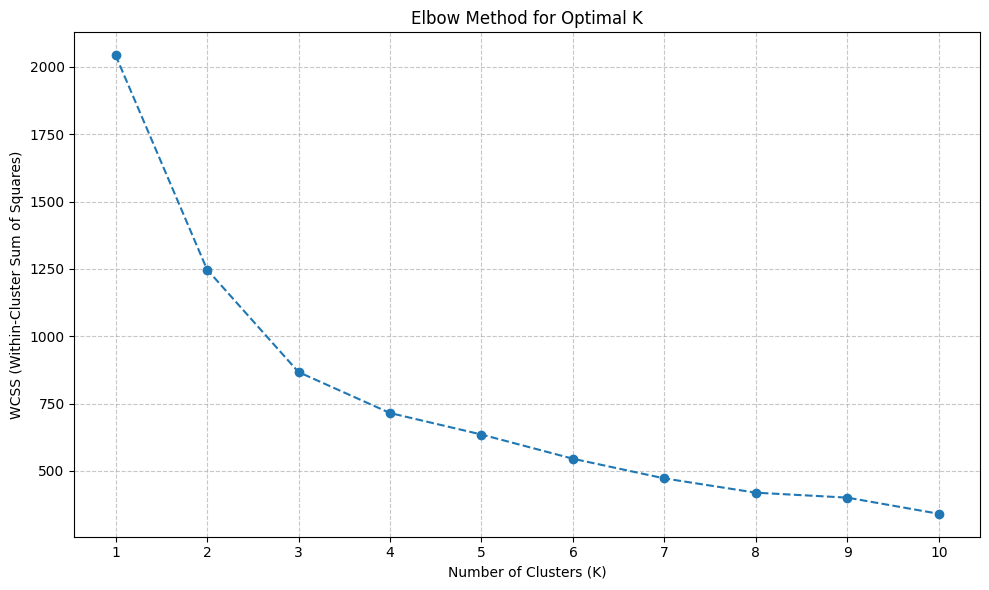

In [104]:
# Calculate WCSS for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

Looking at the elbow plot, the 'elbow' appears to be around K=3 or K=4. Let's choose 4 clusters for now. We will train the K-Means model with 4 clusters.

### Train the K-Means model and assign cluster labels to customers

In [105]:
# Initialize KMeans with the chosen number of clusters (e.g., 4)
k_clusters = 4 # Based on the elbow method
kmeans_model = KMeans(n_clusters=k_clusters, init='k-means++', random_state=42)

# Fit the model and predict clusters
rfm_table['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

print(f"K-Means model trained with {k_clusters} clusters. Cluster labels added to rfm_table.")
display(rfm_table.head())

K-Means model trained with 4 clusters. Cluster labels added to rfm_table.


,CustomerID,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,IsHighValue,Cluster
0,C10001,22885.81,3,116,2,2,4,335,8,True,0
1,C10003,12061.04,1,32,4,1,3,513,8,False,3
2,C10004,10579.97,2,39,4,1,3,423,8,False,3
3,C10005,14154.57,2,296,1,1,3,124,5,False,2
4,C10006,27389.29,3,30,4,2,4,535,10,True,0


### Analyze each cluster
Now that we have assigned cluster labels, let's analyze the characteristics of each cluster to understand the customer segments.

Average RFM values per cluster:


,Cluster,Recency,Frequency,Monetary
0,0,71.055901,2.962733,18482.903851
1,1,74.838710,3.935484,41432.314839
2,2,231.423963,1.382488,8196.505207
3,3,72.883817,1.493776,7518.178382


Number of customers per cluster:


,Cluster,Count
2,0,161
3,1,62
1,2,217
0,3,241


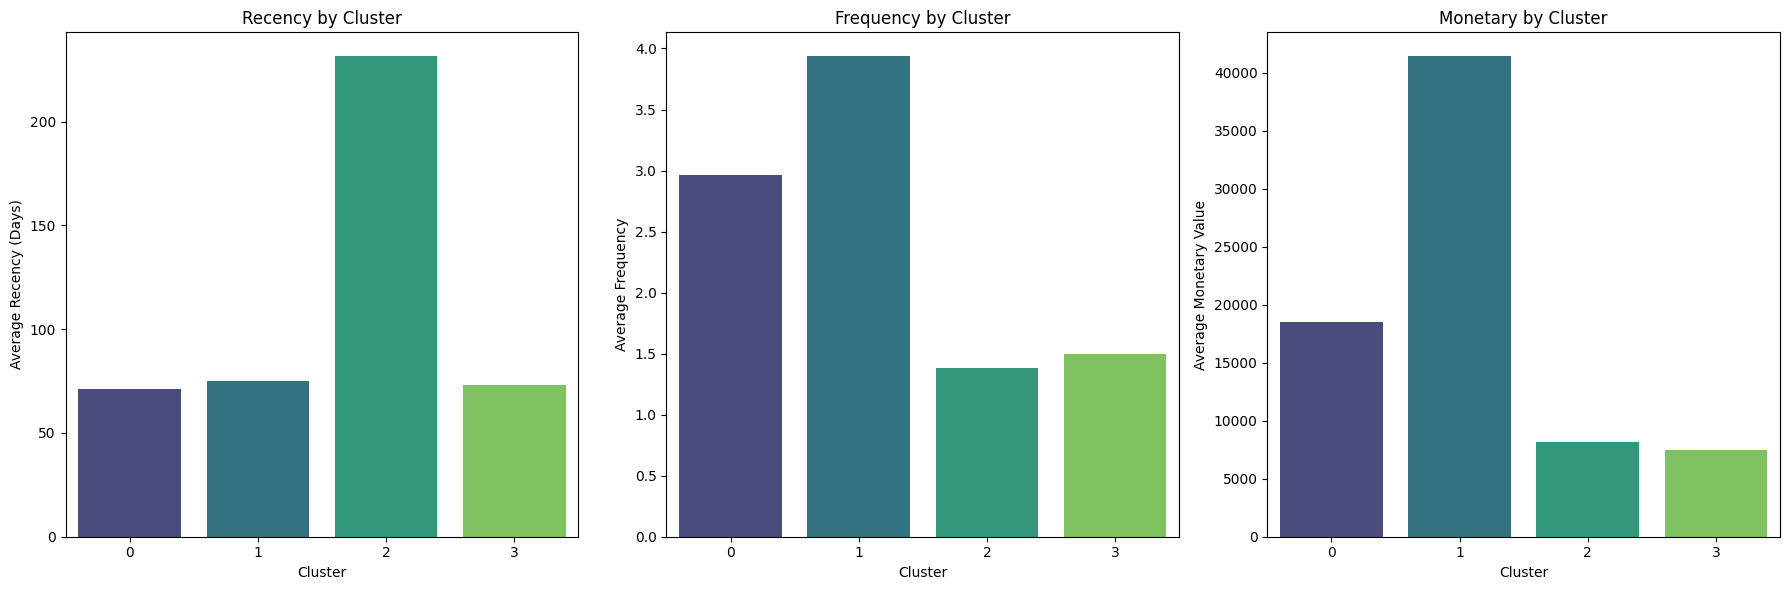

In [106]:
# Calculate the mean of R, F, M for each cluster
cluster_analysis = rfm_table.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

print("Average RFM values per cluster:")
display(cluster_analysis)

# Also count the number of customers in each cluster
cluster_counts = rfm_table['Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Count']

print("Number of customers per cluster:")
display(cluster_counts.sort_values(by='Cluster'))

# Visualize the cluster characteristics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='Cluster', y='Recency', data=cluster_analysis, ax=axes[0], palette='viridis')
axes[0].set_title('Recency by Cluster')
axes[0].set_ylabel('Average Recency (Days)')

sns.barplot(x='Cluster', y='Frequency', data=cluster_analysis, ax=axes[1], palette='viridis')
axes[1].set_title('Frequency by Cluster')
axes[1].set_ylabel('Average Frequency')

sns.barplot(x='Cluster', y='Monetary', data=cluster_analysis, ax=axes[2], palette='viridis')
axes[2].set_title('Monetary by Cluster')
axes[2].set_ylabel('Average Monetary Value')

plt.tight_layout()
plt.show()

## 6. Cluster Interpretation

Based on the `cluster_analysis` and `cluster_counts` results, here's a detailed interpretation of each customer cluster:

---

### **Cluster 0**

*   **Number of Customers**: 161 (Moderately Sized)
*   **Average Recency**: ~71 days (Moderately Recent)
*   **Average Frequency**: ~3 purchases (Good Frequency)
*   **Average Monetary**: ~$18,482 (High Monetary Value)
*   **Customer Behavior**: These customers engage regularly with the business and spend a significant amount. They are active but not necessarily the top spenders or most frequent buyers.
*   **Spending Pattern**: Consistent high-value purchases.
*   **Purchase Frequency**: Above average, indicating a reliable customer base.
*   **Recency Pattern**: They have made a purchase relatively recently, showing continued engagement.
*   **Possible Customer Type**: **Active & Valuable Customers**
*   **Business Value of the Segment**: A strong, consistent segment that contributes significantly to revenue. They are prime candidates for loyalty programs, cross-selling, and up-selling, and efforts should be made to prevent them from moving to 'Lapsed'.

---

### **Cluster 1**

*   **Number of Customers**: 62 (Smallest but Most Exclusive Segment)
*   **Average Recency**: ~75 days (Very Recent)
*   **Average Frequency**: ~4 purchases (Highest Frequency)
*   **Average Monetary**: ~$41,432 (Highest Monetary Value)
*   **Customer Behavior**: These are the most engaged and highest-spending customers. They buy frequently and spend the most per customer.
*   **Spending Pattern**: Very high-value, consistent, and frequent purchases.
*   **Purchase Frequency**: The highest among all segments, demonstrating strong loyalty.
*   **Recency Pattern**: Very recent activity, indicating strong ongoing engagement.
*   **Possible Customer Type**: **Champions / High-Value Loyal Customers**
*   **Business Value of the Segment**: This is your most valuable customer segment. They drive a disproportionately large amount of revenue. Focus on retaining them, providing exclusive offers, and encouraging referrals. Nurturing this segment is critical for long-term growth.

---

### **Cluster 2**

*   **Number of Customers**: 217 (Largest Segment)
*   **Average Recency**: ~231 days (Least Recent - Lapsed)
*   **Average Frequency**: ~1.4 purchases (Lowest Frequency)
*   **Average Monetary**: ~$8,196 (Lowest Monetary Value)
*   **Customer Behavior**: These customers have not purchased in a long time, and their overall purchase frequency and monetary contribution are very low. They are likely disengaged.
*   **Spending Pattern**: Low-value and infrequent purchases, if any in the recent past.
*   **Purchase Frequency**: Very low, suggesting minimal engagement.
*   **Recency Pattern**: Significant time has passed since their last purchase, indicating they are lapsing or have churned.
*   **Possible Customer Type**: **Lapsed / At-Risk Customers**
*   **Business Value of the Segment**: While currently low in value, this large segment represents potential. Strategies should focus on re-engagement campaigns (e.g., win-back offers, personalized discounts) to prevent complete churn or reactivate them.

---

### **Cluster 3**

*   **Number of Customers**: 241 (Second Largest Segment)
*   **Average Recency**: ~73 days (Recent)
*   **Average Frequency**: ~1.5 purchases (Low Frequency)
*   **Average Monetary**: ~$7,518 (Lowest Monetary Value)
*   **Customer Behavior**: These customers have made a recent purchase but have a very low overall purchase frequency and monetary value. They could be new customers or one-time buyers.
*   **Spending Pattern**: Low-value, often single or very few purchases.
*   **Purchase Frequency**: Very low, typically one or two transactions.
*   **Recency Pattern**: Recent activity, indicating they are new or have just made a purchase after a long gap.
*   **Possible Customer Type**: **New / One-Time Buyers / Occasional Shoppers**
*   **Business Value of the Segment**: This segment holds potential for growth. The focus should be on converting them into more frequent and higher-spending customers through onboarding campaigns, personalized recommendations, and incentives for repeat purchases.